# Step 2 - Grid and Boundary Setup

Before solving the PDE we need:
1. A stock price grid S and a time grid t
2. The terminal payoff at expiry
3. The boundary conditions at S=0 and S=S_max

In [6]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.core import OptionParams, GridParams, payoff, make_stock_grid, boundary_values

## Parameters

In [7]:
K     = 100
r     = 0.05
sigma = 0.20
T     = 1.0
S_max = 3 * K

M = 10   # stock grid points (small so we can inspect the values)
N = 5    # time steps

## 1. Stock and Time Grids

In [8]:
grid = GridParams(S_max=S_max, M=M, N=N)

call_opt = OptionParams(
    S0=100, K=K, T=T, r=r, sigma=sigma,
    option_type="call", exercise_type="european"
)

put_opt = OptionParams(
    S0=100, K=K, T=T, r=r, sigma=sigma,
    option_type="put", exercise_type="european"
)


## 2. Terminal Payoff at t = T

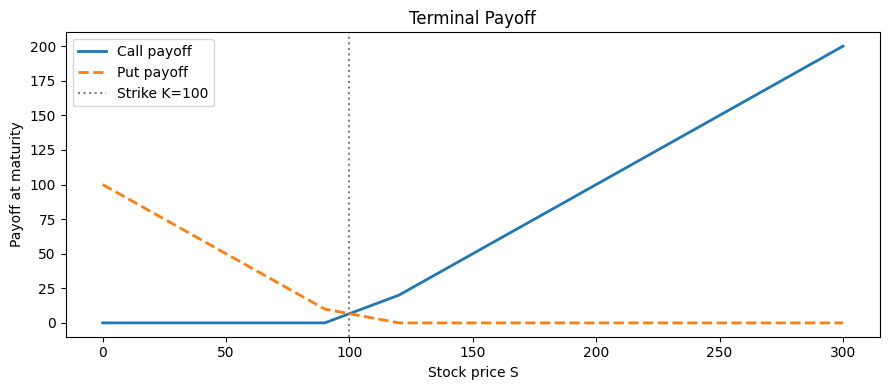

In [9]:
from src.core import make_stock_grid
S = make_stock_grid(grid)

call_payoff = payoff(S, K, option_type="call")
put_payoff  = payoff(S, K, option_type="put")

plt.figure(figsize=(9, 4))
plt.plot(S, call_payoff, label="Call payoff", lw=2)
plt.plot(S, put_payoff, label="Put payoff", lw=2, ls="--")
plt.axvline(K, color="gray", ls=":", label=f"Strike K={K}")
plt.xlabel("Stock price S")
plt.ylabel("Payoff at maturity")
plt.title("Terminal Payoff")
plt.legend()
plt.tight_layout()
plt.savefig('../results/02_payoff.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Boundary Conditions over Time

We evaluate the boundary values at each time step to see how they evolve.

- **S = 0**: call = 0 always; put = K·e^{-rτ} (present value of strike)
- **S = S_max**: call = S_max - K·e^{-rτ}; put = 0 always

In [10]:
t_grid = np.linspace(0, T, N + 1)

call_left = []
call_right = []
put_left = []
put_right = []

for t in t_grid:
    l, u = boundary_values(t, call_opt, grid)
    call_left.append(l)
    call_right.append(u)

    l, u = boundary_values(t, put_opt, grid)
    put_left.append(l)
    put_right.append(u)

call_left = np.array(call_left)
call_right = np.array(call_right)
put_left = np.array(put_left)
put_right = np.array(put_right)

## 4. Visualising the Full Grid

Each cell in this mesh will hold an option value. We start by filling in the terminal row (payoff at t=T) and the two boundary columns.

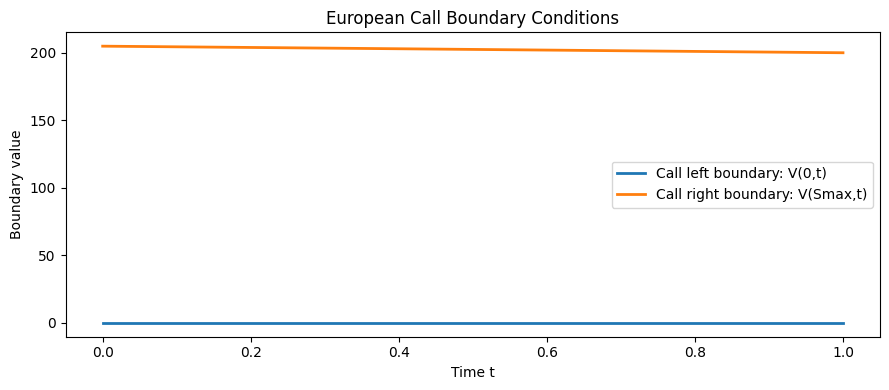

In [11]:
plt.figure(figsize=(9, 4))
plt.plot(t_grid, call_left, label="Call left boundary: V(0,t)", lw=2)
plt.plot(t_grid, call_right, label="Call right boundary: V(Smax,t)", lw=2)
plt.xlabel("Time t")
plt.ylabel("Boundary value")
plt.title("European Call Boundary Conditions")
plt.legend()
plt.tight_layout()
plt.savefig('../results/02_call_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

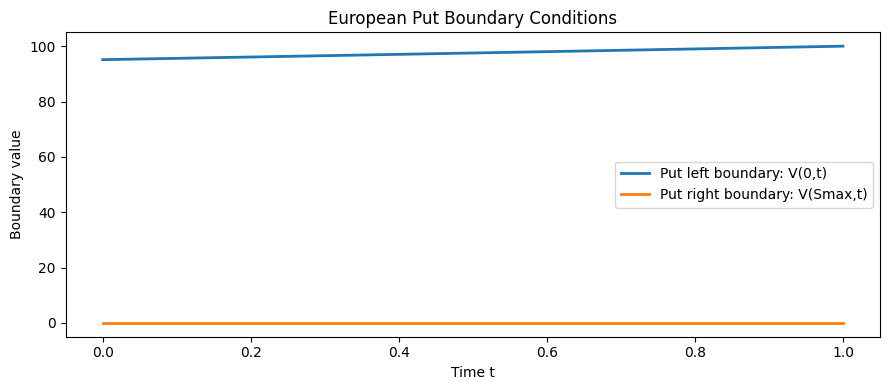

In [12]:
plt.figure(figsize=(9, 4))
plt.plot(t_grid, put_left, label="Put left boundary: V(0,t)", lw=2)
plt.plot(t_grid, put_right, label="Put right boundary: V(Smax,t)", lw=2)
plt.xlabel("Time t")
plt.ylabel("Boundary value")
plt.title("European Put Boundary Conditions")
plt.legend()
plt.tight_layout()
plt.savefig('../results/02_put_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
for t in [0.0, T/2, T]:
    cl, cu = boundary_values(t, call_opt, grid)
    pl, pu = boundary_values(t, put_opt, grid)

    print(f"t = {t:.2f}")
    print(f"  Call: left={cl:.4f}, right={cu:.4f}")
    print(f"  Put : left={pl:.4f}, right={pu:.4f}")

t = 0.00
  Call: left=0.0000, right=204.8771
  Put : left=95.1229, right=0.0000
t = 0.50
  Call: left=0.0000, right=202.4690
  Put : left=97.5310, right=0.0000
t = 1.00
  Call: left=0.0000, right=200.0000
  Put : left=100.0000, right=0.0000
